# Fine-tuning mBART50 for Multilingual NMT

Dataset: Multilingual (OPUS-100)
Training: Balanced Loss
Search: Top-p / Top-k Sampling

In [1]:
!pip install -q transformers sentencepiece datasets accelerate evaluate sacrebleu matplotlib pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 4.1 MB/s eta 0:00:00


In [2]:
!pip install SentencePiece evaluate sacrebleu accelerate

In [3]:
!pip install torch==2.3.1 torchvision==0.18.1 torchaudio==2.3.1 --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.9/780.9 MB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 112.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 93.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 77.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 41.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 102.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 15.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 15.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196

In [4]:
import os

# Output directory
if os.path.exists('/kaggle/working'):
    OUTPUT_DIR = '/kaggle/working/outputs'
else:
    OUTPUT_DIR = './outputs'

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Output directory: {OUTPUT_DIR}')


Output directory: /kaggle/working/outputs


## Dataset

In [5]:
from datasets import load_dataset, concatenate_datasets

# (dataset_config, src_lang, tgt_lang) - use config names that exist in OPUS-100
LANG_CONFIGS = [("en-vi", "en", "vi"), ("en-fr", "en", "fr"), ("de-en", "de", "en")]
MAX_SAMPLES_PER_PAIR = 50000

def load_multilingual_dataset():
    all_train, all_val, all_test = [], [], []
    for config, src, tgt in LANG_CONFIGS:
        pair = f"{src}-{tgt}"
        ds = load_dataset("Helsinki-NLP/opus-100", config)
        train = ds["train"].select(range(min(len(ds["train"]), MAX_SAMPLES_PER_PAIR)))
        val = ds["validation"] if "validation" in ds else ds["test"].select(range(1000))
        test = ds["test"].select(range(min(len(ds["test"]), 2000)))
        train = train.map(lambda x: {"pair": pair, "src": x["translation"][src], "tgt": x["translation"][tgt]}, remove_columns=["translation"])
        val = val.map(lambda x: {"pair": pair, "src": x["translation"][src], "tgt": x["translation"][tgt]}, remove_columns=["translation"])
        test = test.map(lambda x: {"pair": pair, "src": x["translation"][src], "tgt": x["translation"][tgt]}, remove_columns=["translation"])

        all_train.append(train)
        all_val.append(val)
        all_test.append(test)

    from datasets import DatasetDict
    return DatasetDict({
        "train": concatenate_datasets(all_train),
        "validation": concatenate_datasets(all_val),
        "test": concatenate_datasets(all_test)
    })

ds = load_multilingual_dataset()
from collections import Counter
pair_counts = Counter(ds["train"]["pair"])
print(f"Train: {len(ds['train'])} | Val: {len(ds['validation'])} | Test: {len(ds['test'])}")
print(f"Per pair: {dict(pair_counts)}")

README.md: 0.00B [00:00, ?B/s]

en-vi/test-00000-of-00001.parquet:   0%|          | 0.00/137k [00:00<?, ?B/s]

en-vi/train-00000-of-00001.parquet:   0%|          | 0.00/59.0M [00:00<?, ?B/s]

en-vi/validation-00000-of-00001.parquet:   0%|          | 0.00/138k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

...

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Train: 150000 | Val: 6000 | Test: 6000
Per pair: {'en-vi': 50000, 'en-fr': 50000, 'de-en': 50000}


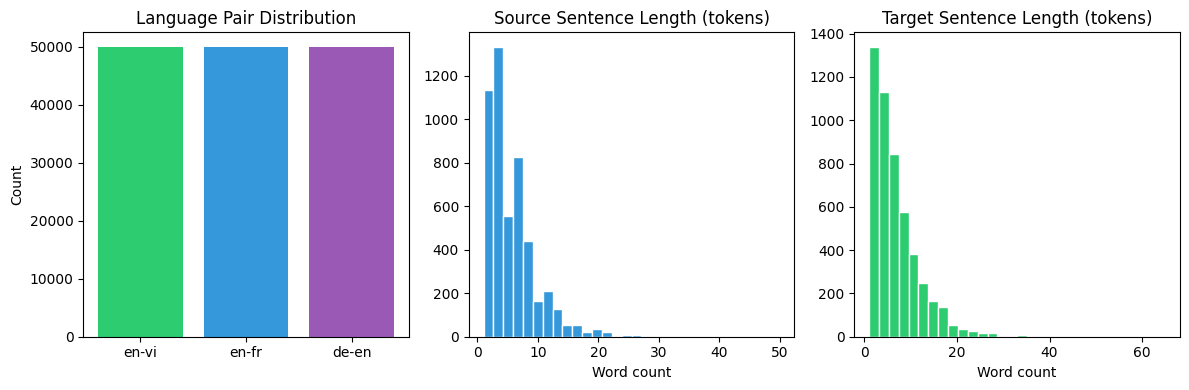

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Language pair distribution
pair_counts = Counter(ds["train"]["pair"])
pairs = list(pair_counts.keys())
counts = list(pair_counts.values())
axes[0].bar(pairs, counts, color=["#2ecc71", "#3498db", "#9b59b6"])
axes[0].set_title("Language Pair Distribution")
axes[0].set_ylabel("Count")

# Source sentence length
src_lens = [len(s.split()) for s in ds["train"]["src"][:5000]]
axes[1].hist(src_lens, bins=30, color="#3498db", edgecolor="white")
axes[1].set_title("Source Sentence Length (tokens)")
axes[1].set_xlabel("Word count")

# Target sentence length
tgt_lens = [len(s.split()) for s in ds["train"]["tgt"][:5000]]
axes[2].hist(tgt_lens, bins=30, color="#2ecc71", edgecolor="white")
axes[2].set_title("Target Sentence Length (tokens)")
axes[2].set_xlabel("Word count")

plt.tight_layout()
plt.show()

## Tokenizer

In [7]:
from transformers import AutoTokenizer

model_name = "facebook/mbart-large-50-many-to-many-mmt"
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False)

LANG_TO_MBART = {"en": "en_XX", "vi": "vi_VN", "fr": "fr_XX", "de": "de_DE"}

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/529 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/649 [00:00<?, ?B/s]

## Encoding

In [8]:
import torch

MAX_LEN = 128

def preprocess_function(examples):
    src_tgt = list(zip(examples["src"], examples["tgt"], examples["pair"]))
    input_ids_list, attention_mask_list, labels_list, pair_list = [], [], [], []
    for src, tgt, pair in src_tgt:
        src_lang, tgt_lang = pair.split("-")
        tokenizer.src_lang = LANG_TO_MBART[src_lang]
        tokenizer.tgt_lang = LANG_TO_MBART[tgt_lang]
        target_lang_token_id = tokenizer.lang_code_to_id[LANG_TO_MBART[tgt_lang]]
        enc = tokenizer(src, padding="max_length", truncation=True, max_length=MAX_LEN)
        dec = tokenizer(text_target=tgt, padding="max_length", truncation=True, max_length=MAX_LEN)
        dec_input_ids = dec["input_ids"]
        if dec_input_ids:
            dec_input_ids[0] = target_lang_token_id
        labels = [-100 if t == tokenizer.pad_token_id else t for t in dec_input_ids]
        input_ids_list.append(enc["input_ids"])
        attention_mask_list.append(enc["attention_mask"])
        labels_list.append(labels)
        pair_list.append(pair)
    return {
        "input_ids": input_ids_list,
        "attention_mask": attention_mask_list,
        "labels": labels_list,
        "pair": pair_list
    }

preprocessed_ds = ds.map(preprocess_function, batched=True, load_from_cache_file=False)

Map:   0%|          | 0/150000 [00:00<?, ? examples/s]

Map:   0%|          | 0/6000 [00:00<?, ? examples/s]

Map:   0%|          | 0/6000 [00:00<?, ? examples/s]

## Model

In [9]:
from transformers import AutoModelForSeq2SeqLM

model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

model.safetensors:   0%|          | 0.00/2.44G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/516 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/261 [00:00<?, ?B/s]

## Balanced Loss

In [10]:
from collections import Counter
import math

pair_counts = Counter(preprocessed_ds["train"]["pair"])
total = len(preprocessed_ds["train"])
pair_weights = {p: math.sqrt(total / c) for p, c in pair_counts.items()}
print(f"Pair weights: {pair_weights}")

Pair weights: {'en-vi': 1.7320508075688772, 'en-fr': 1.7320508075688772, 'de-en': 1.7320508075688772}


In [11]:
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments

class BalancedLossSeq2SeqTrainer(Seq2SeqTrainer):
    def __init__(self, pair_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.pair_weights = pair_weights or {}

    def prediction_step(self, model, inputs, prediction_loss_only=None, ignore_keys=None, **gen_kwargs):
        inputs = {k: v for k, v in inputs.items() if k != "pair"}
        return super().prediction_step(model, inputs, prediction_loss_only, ignore_keys, **gen_kwargs)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        if "pair" not in inputs:
            return super().compute_loss(model, inputs, return_outputs=return_outputs, **kwargs)
        pairs = inputs.pop("pair")
        outputs = model(**inputs)
        logits = outputs.logits
        labels = inputs["labels"]
        loss_fct = torch.nn.CrossEntropyLoss(ignore_index=-100, reduction="none")
        loss_per_token = loss_fct(logits.view(-1, logits.size(-1)), labels.view(-1))
        loss_per_token = loss_per_token.view(labels.size(0), -1)
        mask = (labels != -100).float()
        loss_per_sample = (loss_per_token * mask).sum(1) / mask.sum(1).clamp(min=1)
        weights = torch.tensor([self.pair_weights.get(p, 1.0) for p in pairs], device=loss_per_sample.device)
        loss = (loss_per_sample * weights).mean()
        return (loss, outputs) if return_outputs else loss

## Evaluate

In [12]:
import numpy as np
import evaluate

metric = evaluate.load("sacrebleu")

def compute_metrics(eval_preds):
    preds, labels = eval_preds
    if isinstance(preds, tuple):
        preds = preds[0]
    preds = np.where(preds != -100, preds, tokenizer.pad_token_id)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True, clean_up_tokenization_spaces=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True, clean_up_tokenization_spaces=True)
    decoded_preds = [p.strip() for p in decoded_preds]
    decoded_labels = [[l.strip()] for l in decoded_labels]
    result = metric.compute(predictions=decoded_preds, references=decoded_labels)
    return {"bleu": result["score"]}

## Trainer

In [13]:
import os
os.environ["WANDB_DISABLED"] = "true"

def collate_fn(examples):
    batch = {
        "input_ids": torch.tensor([e["input_ids"] for e in examples]),
        "attention_mask": torch.tensor([e["attention_mask"] for e in examples]),
        "labels": torch.tensor([e["labels"] for e in examples]),
    }
    if examples and "pair" in examples[0]:
        batch["pair"] = [e["pair"] for e in examples]
    return batch

training_args = Seq2SeqTrainingArguments(
    output_dir=OUTPUT_DIR,
    logging_steps=500,
    predict_with_generate=True,
    remove_unused_columns=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    save_total_limit=1,
    num_train_epochs=2,
    load_best_model_at_end=True,
    report_to="none"
)

trainer = BalancedLossSeq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=preprocessed_ds["train"],
    eval_dataset=preprocessed_ds["validation"],
    data_collator=collate_fn,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    pair_weights=pair_weights
)

trainer.train()

# Save best model
best_path = os.path.join(OUTPUT_DIR, 'best_model')
trainer.save_model(best_path)
tokenizer.save_pretrained(best_path)
print(f'Best model saved to: {best_path}')


Epoch,Training Loss,Validation Loss,Bleu
1,2.856512,1.710188,26.705409
2,1.995763,1.666032,27.631751


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model saved to: /kaggle/working/outputs/best_model


## Training History

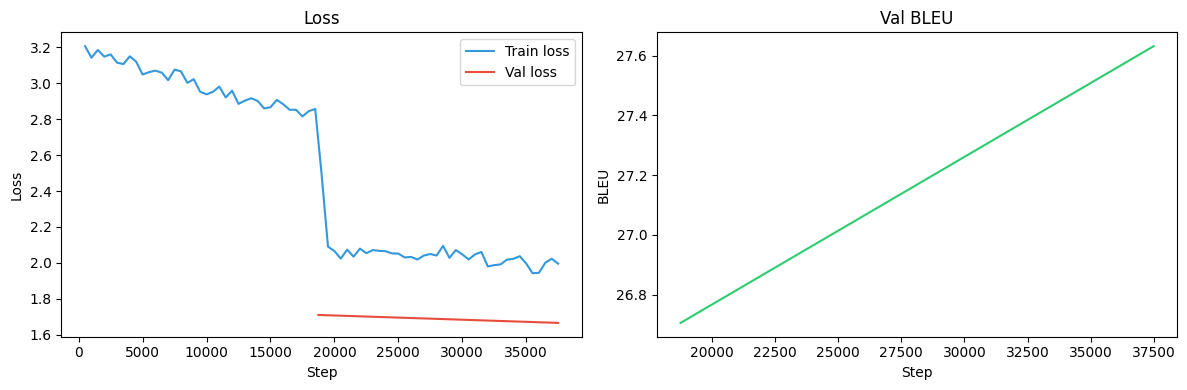

In [14]:
# Training history: Loss and BLEU
history = trainer.state.log_history
train_steps = [h["step"] for h in history if "loss" in h]
train_loss = [h["loss"] for h in history if "loss" in h]
eval_steps = [h["step"] for h in history if "eval_loss" in h]
eval_loss = [h["eval_loss"] for h in history if "eval_loss" in h]
eval_bleu = [h["eval_bleu"] for h in history if "eval_bleu" in h]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_steps, train_loss, label="Train loss", color="#3498db")
if eval_steps:
    axes[0].plot(eval_steps, eval_loss, label="Val loss", color="#e74c3c")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].set_title("Loss")

if eval_bleu:
    axes[1].plot(eval_steps, eval_bleu, color="#2ecc71")
    axes[1].set_xlabel("Step")
    axes[1].set_ylabel("BLEU")
    axes[1].set_title("Val BLEU")
plt.tight_layout()
plt.show()

## Inference - Sampling

### Top-p (Nucleus) Sampling

Sample from tokens whose cumulative probability exceeds threshold p. Adapts to distribution shape.

In [15]:
src_text = "I'm so tired today."
tokenizer.src_lang = "en_XX"
tokenizer.tgt_lang = "vi_VN"
encoded = tokenizer(src_text, return_tensors="pt")
encoded = {k: v.to(model.device) for k, v in encoded.items()}

output = model.generate(
    **encoded,
    forced_bos_token_id=tokenizer.lang_code_to_id["vi_VN"],
    do_sample=True,
    top_p=0.9,
    temperature=0.7,
    max_length=MAX_LEN
)
print(tokenizer.decode(output[0], skip_special_tokens=True))

Hôm nay tôi quá mệt mỏi.


### Top-k Sampling

Sample from k highest probability tokens. Fixed candidate set size.

In [16]:
output = model.generate(
    **encoded,
    forced_bos_token_id=tokenizer.lang_code_to_id["vi_VN"],
    do_sample=True,
    top_k=50,
    temperature=0.7,
    max_length=MAX_LEN
)
print(tokenizer.decode(output[0], skip_special_tokens=True))

Hôm nay tôi quá mệt mỏi.


### Top-p + Top-k (Combined)

Top-k filters first, then top-p. Commonly used together in LLMs.

In [17]:
output = model.generate(
    **encoded,
    forced_bos_token_id=tokenizer.lang_code_to_id["vi_VN"],
    do_sample=True,
    top_p=0.9,
    top_k=50,
    temperature=0.7,
    max_length=MAX_LEN
)
print(tokenizer.decode(output[0], skip_special_tokens=True))

Hôm nay tôi quá mệt mỏi.


### Inference Comparison

Compare outputs from Top-p, Top-k, and Top-p+k sampling.

In [18]:
# Inference comparison: all sampling methods
import pandas as pd

test_sentences = ["I go to school", "How are you?", "The weather is nice today"]
tokenizer.src_lang = "en_XX"
tokenizer.tgt_lang = "vi_VN"

results = []
for src in test_sentences:
    encoded = tokenizer(src, return_tensors="pt")
    encoded = {k: v.to(model.device) for k, v in encoded.items()}
    out_top_p = model.generate(**encoded, forced_bos_token_id=tokenizer.lang_code_to_id["vi_VN"],
        do_sample=True, top_p=0.9, temperature=0.7, max_length=MAX_LEN)
    out_top_k = model.generate(**encoded, forced_bos_token_id=tokenizer.lang_code_to_id["vi_VN"],
        do_sample=True, top_k=50, temperature=0.7, max_length=MAX_LEN)
    out_combined = model.generate(**encoded, forced_bos_token_id=tokenizer.lang_code_to_id["vi_VN"],
        do_sample=True, top_p=0.9, top_k=50, temperature=0.7, max_length=MAX_LEN)
    results.append({
        "Source": src,
        "Top-p": tokenizer.decode(out_top_p[0], skip_special_tokens=True),
        "Top-k": tokenizer.decode(out_top_k[0], skip_special_tokens=True),
        "Top-p+k": tokenizer.decode(out_combined[0], skip_special_tokens=True)
    })

pd.DataFrame(results)

,Source,Top-p,Top-k,Top-p+k
0,I go to school,Tôi đi học,Tôi đi học,Tôi đi học
1,How are you?,Cô khỏe chứ?,Cô khỏe chứ?,Cô khỏe chứ?
2,The weather is nice today,Hôm nay trời đẹp lắm.,Hôm nay trời đẹp lắm.,Hôm nay trời đẹp lắm
